# Part 4: Choosing adventures
## Word frequency over time

On this notebook we are aiming to answer: *Does the frequency of certain words change over time?*

### Loading libraries and dataset

For this first part we load our libraries and our data, from the data folder. Using the utils function `edit_year` created from Part 2 to modify year values to ints. However we added the extra step of dropping duplicate rows, for future steps.

In [1]:
# imports
import ipywidgets as widgets
from ipywidgets import interact
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from tqdm import tqdm
from collections import Counter
from utils import *

plt.style.use('seaborn-v0_8-dark')

# read in SOTU.csv
sou_original = pd.read_csv('./data/SOTU.csv')
sou = edit_year(sou_original).drop_duplicates() #

### Exploration

We noticed there are years where there's more than one president listed. Since we are analysing the yearly trend of most common words in speeches, regardless of the president, we decided to combine the texts of the speeches and add the word counts.

In [2]:
sou.groupby('Year').filter(lambda x: x['Year'].count() > 1)

,President,Year,Text,Word Count
43,Ronald Reagan,1981,"\nMr. Speaker, Mr. President, distinguished Me...",4369
44,Jimmy Carter,1981,\nTo the Congress of the United States:\nThe S...,33065
68,John F. Kennedy,1961,\n[As delivered in person before a joint sessi...,5098
69,Dwight D. Eisenhower,1961,\nTo the Congress of the United States:\nOnce ...,6037
78,Dwight D. Eisenhower,1953,"\nMr. President, Mr. Speaker, Members of the E...",6780
79,Harry S Truman,1953,\nTo the Congress of the United States:\nI hav...,9438


In [3]:
new_sou = (
    sou.groupby("Year")
    .agg({
        "President": lambda x: " | ".join(sorted(set(x))),   # merge unique presidents
        "Text": lambda x: " ".join(x),                      # concatenate speeches
        "Word Count": "sum"                                 # sum word counts
    })
    .reset_index()
)
new_sou.groupby('Year').filter(lambda x: x['Year'].count() > 1)

,Year,President,Text,Word Count


In [4]:
new_sou[new_sou["Year"]==1981]

,Year,President,Text,Word Count
188,1981,Jimmy Carter | Ronald Reagan,"\nMr. Speaker, Mr. President, distinguished Me...",37434


The idea is to obtain the top n most common words of each year so that we can analyse later their frequency throughout across years.
For that, we get first obtain the list of years (unique values) present in our dataset, so that we can iterate over them. We also pick a value for $n$, which will be limiting the top most common words for each year.

Since we have the speeches' data for 232 years, assuming the "worst case scenario" where each year there are different $n$ most common words, we could have up to $n \times 232$ word counts, which would make our analysis harder. Given this upper bound we decided to limit the top to 5 for each year.

In [5]:
unique_years_sou = sou.Year.unique() # 232
n = 5
w_freq = {}

for year in tqdm(unique_years_sou):
    w_freq[year] = get_most_common_words(df=new_sou, year=year, n=n)

100%|██████████| 232/232 [07:11<00:00,  1.86s/it]


After obtaining the most frequent words for each year (using the function created on part 2) and storing it in a dictionary, we now use it to create a dataframe so it's easier to work with. 

In [6]:
data = [[k, *v] for k, lst in w_freq.items() for v in lst]

df_w_freq = pd.DataFrame(data, columns=['Year','Word','Count'])
# df_w_freq.to_csv("part_4_data.csv",index=False, sep=',') # used to not run multiple times cell 2 since it takes ~7 mins

We then include the total number of words in the speech, so that we can calculate relative word frequency.

In [7]:
newdf_w_freq = pd.merge(df_w_freq, new_sou[["Year","Word Count"]], how="left", on="Year").drop_duplicates()
newdf_w_freq["Relative Freq"] = newdf_w_freq["Count"]/newdf_w_freq["Word Count"]
newdf_w_freq

,Year,Word,Count,Word Count,Relative Freq
0,2024,president,58,8003,0.007247
1,2024,year,45,8003,0.005623
2,2024,america,44,8003,0.005498
3,2024,american,34,8003,0.004248
4,2024,people,33,8003,0.004123
...,...,...,...,...,...
1155,1790,public,5,1069,0.004677
1156,1790,measure,5,1069,0.004677
1157,1790,great,4,1069,0.003742
1158,1790,united,4,1069,0.003742


Let's have a look at some summarizing values of the distribution of the relative frequency. As we can see, even with words being most common during the speech, relative to the number of words of the speech itself 75% of those words are still below 1% of the speech, with the maximum being 1.3%.

In the next cell we can see that since 1996, there hasn't been a single word that has appeared for more than 1% of the speech, with the maximum value we just mentioned corresponding to the speech given in 1793. We do find that there are repeated words that are above this threshold, like "war", "year", and "states".

In [8]:
newdf_w_freq["Relative Freq"].describe()

count    1160.000000
mean        0.004945
std         0.001504
min         0.002489
25%         0.003899
50%         0.004654
75%         0.005704
max         0.013817
Name: Relative Freq, dtype: float64

In [9]:
newdf_w_freq[newdf_w_freq["Relative Freq"] > 0.01].sort_values(by='Year',ascending=False)

,Year,Word,Count,Word Count,Relative Freq
140,1996,work,64,6233,0.010268
250,1974,year,70,5083,0.013771
260,1971,government,55,4359,0.012618
261,1971,people,44,4359,0.010094
270,1969,year,45,3996,0.011261
390,1944,war,51,3691,0.013817
395,1943,war,46,4465,0.010302
780,1865,states,95,9176,0.010353
825,1856,states,105,10396,0.010100
830,1855,states,127,11506,0.011038


We can also take a look at the boxplot of the same value.

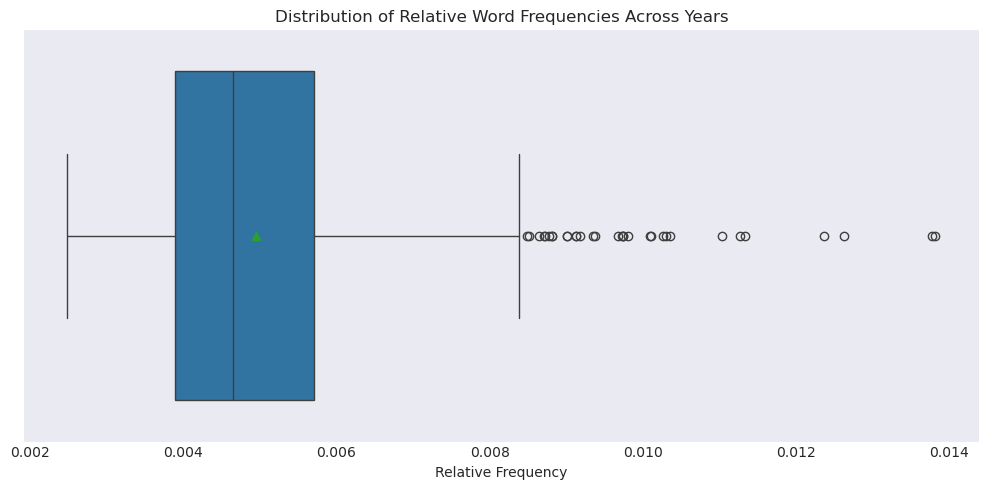

In [10]:
# df_w_freq = pd.read_csv("part_4_data.csv",sep=',') # used to not run multiple times cell 2
plt.figure(figsize=(10, 5))

fig1 = sns.boxplot(x=newdf_w_freq["Relative Freq"], showmeans=True)

plt.title("Distribution of Relative Word Frequencies Across Years")
plt.xlabel("Relative Frequency")
plt.tight_layout()
plt.savefig("outputs/relative_word_frequency_boxplot.png")
plt.show()

### 

After exploring a little bit, we would like to filter out the words that only appear in a small number of years. We are considering "small" anything lower than 4, this was taken somewhat arbitrarily and could be easily modifiable. However, the chain of thought for that number was considering the duration of presidential periods in the US.

In [11]:
count_df = newdf_w_freq.groupby("Word", as_index=False,).count().sort_values(by="Year",ascending=False)
words_more_4y = count_df["Word"][count_df['Year']>4].tolist() 
newdf_w_freq= newdf_w_freq[newdf_w_freq["Word"].isin(words_more_4y)]

## Plot of Relative Frequencies

After the previous exploration and relative cleaning, we finally arrive to a visualization where one can filter by word (words ordered by the number of yearly speeches it appeared on), on the background we can see the different plots for all the words and when selecting one, it shows highlighted. This is an interactive plot.

In [12]:
%matplotlib widget

@interact(
    word=widgets.Dropdown(
        options=words_more_4y,
        description="Highlight"
    )
)
def highlight_plot(word):
    plt.figure(figsize=(14, 7))
    
    # faded lines
    sns.lineplot(
        data=newdf_w_freq,
        x="Year",
        y="Relative Freq",
        hue="Word",
        alpha=0.2,
        legend=False
    )
    
    # highlight selected word
    df_focus = newdf_w_freq[newdf_w_freq["Word"] == word]
    sns.lineplot(
        data=df_focus,
        x="Year",
        y="Relative Freq",
        color="red",
        linewidth=3,
        marker="o",
        label=word
    )

    plt.title(f"Focus: '{word}' Across Presidential Speeches", fontsize=20)
    plt.savefig("outputs/word_frequency_timeseries.png")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Highlight', options=('government', 'year', 'states', 'united', 'co…